# 01 - Bundle pricing EDA

Load bundle_data.json and build two tidy tables:
- bundle_df: one row per bundle
- bundle_items_df: one row per bundle-item pair

Then compute derived pricing fields and make four plots.

Field reference (from bundle_data.json):
- bundle_price: sum of standalone game prices (before the bundle discount)
- bundle_final_price: what you actually pay for the bundle
- bundle_discount: the reported discount percentage (e.g. '10%')
- items[].discounted_price: the standalone price of each game

In [1]:
import os, ast, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_RAW = '../data/raw'
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

## Load bundle_data.json

In [2]:
bundle_path = os.path.join(DATA_RAW, 'bundle_data.json')

raw = []
with open(bundle_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            raw.append(ast.literal_eval(line))

print(f'loaded {len(raw)} bundle records')
print('\nfirst record keys:', list(raw[0].keys()))
print('first record (non-list fields):')
import json
print(json.dumps({k: v for k, v in raw[0].items() if not isinstance(v, list)}, indent=2))
print('\nfirst item in bundle:', raw[0]['items'][0])


loaded 615 bundle records

first record keys: ['bundle_final_price', 'bundle_url', 'bundle_price', 'bundle_name', 'bundle_id', 'items', 'bundle_discount']
first record (non-list fields):
{
  "bundle_final_price": "$66.46",
  "bundle_url": "http://store.steampowered.com/bundle/450/?utm_source=SteamDB&utm_medium=SteamDB&utm_campaign=SteamDB%20Bundles%20Page",
  "bundle_price": "$73.86",
  "bundle_name": "Dharker Studio 2015 Complete",
  "bundle_id": "450",
  "bundle_discount": "10%"
}

first item in bundle: {'genre': 'Adventure, Indie, RPG', 'item_id': '326950', 'discounted_price': '$8.99', 'item_url': 'http://store.steampowered.com/app/326950', 'item_name': 'Sword of Asumi'}


## Parse helpers

bundle_price and bundle_final_price are strings like '$73.86'. bundle_discount is a string like '10%'. discounted_price on each item is also a dollar string.

In [3]:
def parse_price(val): # converts pricing data in strings to float
    if val is None:
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    val = str(val).strip()
    if val.lower() in ('free', 'free to play', ''):
        return 0.0
    cleaned = re.sub(r'[^0-9.]', '', val)
    try:
        return float(cleaned)
    except ValueError:
        return np.nan


def parse_discount(val):
    if val is None:
        return np.nan
    if isinstance(val, float) and val <= 1.0:
        return val
    if isinstance(val, (int, float)):
        return val / 100.0
    val = str(val).strip().replace('%', '')
    try:
        v = float(val)
        return v / 100.0 if v > 1 else v
    except ValueError:
        return np.nan


print('parse_price test:', parse_price('$73.86'))
print('parse_discount test:', parse_discount('10%'))


parse_price test: 73.86
parse_discount test: 0.1


## Build bundle_df and bundle_items_df

In [4]:
bundle_rows = []
item_rows = []

for rec in raw:
    bundle_id   = rec.get('bundle_id')
    bundle_name = rec.get('bundle_name')
    bundle_url  = rec.get('bundle_url')
    price       = parse_price(rec.get('bundle_price'))
    final_price = parse_price(rec.get('bundle_final_price'))
    discount    = parse_discount(rec.get('bundle_discount'))
    items       = rec.get('items') or []

    bundle_rows.append({
        'bundle_id':   bundle_id,
        'bundle_name': bundle_name,
        'bundle_url':  bundle_url,
        'price':       price,
        'final_price': final_price,
        'discount':    discount,
        'n_items':     len(items)
    })

    for item in items:
        item_rows.append({
            'bundle_id':  bundle_id,
            'item_id':    item.get('item_id'),
            'item_name':  item.get('item_name'),
            'item_price': parse_price(item.get('discounted_price')),
            'genre':      item.get('genre'),
            'item_url':   item.get('item_url')
        })

bundle_df = pd.DataFrame(bundle_rows)
bundle_items_df = pd.DataFrame(item_rows)

print('bundle_df shape:', bundle_df.shape)
print(bundle_df.head(3))
print('\nbundle_items_df shape:', bundle_items_df.shape)
print(bundle_items_df.head(5))


bundle_df shape: (615, 7)
  bundle_id                              bundle_name  \
0       450             Dharker Studio 2015 Complete   
1      1473  Naruto Shippuden Uncut Season 4, Vol. 3   
2      1474  Naruto Shippuden Uncut Season 4, Vol. 4   

                                          bundle_url  price  final_price  \
0  http://store.steampowered.com/bundle/450/?utm_...  73.86        66.46   
1  http://store.steampowered.com/bundle/1473/?utm...  25.87        20.15   
2  http://store.steampowered.com/bundle/1474/?utm...  25.87        20.15   

   discount  n_items  
0      0.10       14  
1      0.22       13  
2      0.22       13  

bundle_items_df shape: (3525, 6)
  bundle_id item_id                           item_name  item_price  \
0       450  326950                      Sword of Asumi        8.99   
1       450  331490         Sword of Asumi - Soundtrack        2.99   
2       450  331491      Sword of Asumi - Graphic Novel        1.99   
3       450  331492  Sword of Asum

## Derived fields

- component_price_sum: sum of standalone prices of all items in the bundle
- abs_discount: component_price_sum - final_price
- implied_discount_rate: abs_discount / component_price_sum
- discount_mismatch: flag where reported and implied rates differ by more than 5pp

Note on the pricing fields: in this dataset `bundle_price` is by construction the sum of the item `discounted_price` values, so `component_price_sum` should equal `price` exactly. That means `implied_discount_rate` is really a re-derivation of the reported `bundle_discount`, and `discount_mismatch` is an internal-consistency check (does the stated discount percentage match the list-versus-final price ratio?), not a comparison of two independent price sources. We verify the identity below.

In [5]:
item_price_sum = (
    bundle_items_df
    .groupby('bundle_id')['item_price']
    .sum()
    .rename('component_price_sum')
)
bundle_df = bundle_df.join(item_price_sum, on='bundle_id')

bundle_df['abs_discount'] = bundle_df['component_price_sum'] - bundle_df['final_price']
bundle_df['implied_discount_rate'] = (
    bundle_df['abs_discount'] / bundle_df['component_price_sum']
)
bundle_df['discount_mismatch'] = (
    (bundle_df['discount'] - bundle_df['implied_discount_rate']).abs() > 0.05
)

cols = ['bundle_id', 'bundle_name', 'n_items', 'component_price_sum',
        'final_price', 'discount', 'implied_discount_rate', 'abs_discount']
print(bundle_df[cols].head(10).to_string())
print('\ndiscount mismatch count:', bundle_df['discount_mismatch'].sum())


  bundle_id                              bundle_name  n_items  component_price_sum  final_price  discount  implied_discount_rate  abs_discount
0       450             Dharker Studio 2015 Complete       14                73.86        66.46      0.10               0.100190          7.40
1      1473  Naruto Shippuden Uncut Season 4, Vol. 3       13                25.87        20.15      0.22               0.221106          5.72
2      1474  Naruto Shippuden Uncut Season 4, Vol. 4       13                25.87        20.15      0.22               0.221106          5.72
3      1437      Pixel Puzzles Ultimate: Starter Kit       10                25.35        15.17      0.40               0.401578         10.18
4      1466  Naruto Shippuden Uncut Season 4, Vol. 1       13                25.87        20.15      0.22               0.221106          5.72
5      1478                           Cosmi Fun Pack        9                71.91        25.20      0.65               0.649562         46.71

In [6]:
# verify bundle_price equals the sum of item discounted_price
price_gap = (bundle_df['price'] - bundle_df['component_price_sum']).abs()
print('max |price - component_price_sum|:', round(price_gap.max(), 4))
print('bundles where they differ by more than 1 cent:', (price_gap > 0.01).sum())

# how close is the reported discount to the price-implied discount?
disc_gap = (bundle_df['discount'] - bundle_df['implied_discount_rate']).abs()
print('max |reported discount - implied discount|:', round(disc_gap.max(), 4))

max |price - component_price_sum|: 0.0
bundles where they differ by more than 1 cent: 0
max |reported discount - implied discount|: 0.0051


In [7]:
print(bundle_df[['n_items', 'component_price_sum', 'final_price',
                 'implied_discount_rate']].describe().round(3))


       n_items  component_price_sum  final_price  implied_discount_rate
count  615.000              615.000      615.000                615.000
mean     5.732               47.018       34.547                  0.245
std      8.013               79.007       53.005                  0.169
min      2.000                1.980        0.840                 -0.000
25%      2.000               12.970        9.455                  0.101
50%      3.000               24.980       19.970                  0.201
75%      5.000               47.625       35.985                  0.301
max     89.000              999.980      575.840                  0.920


## Four diagnostic plots

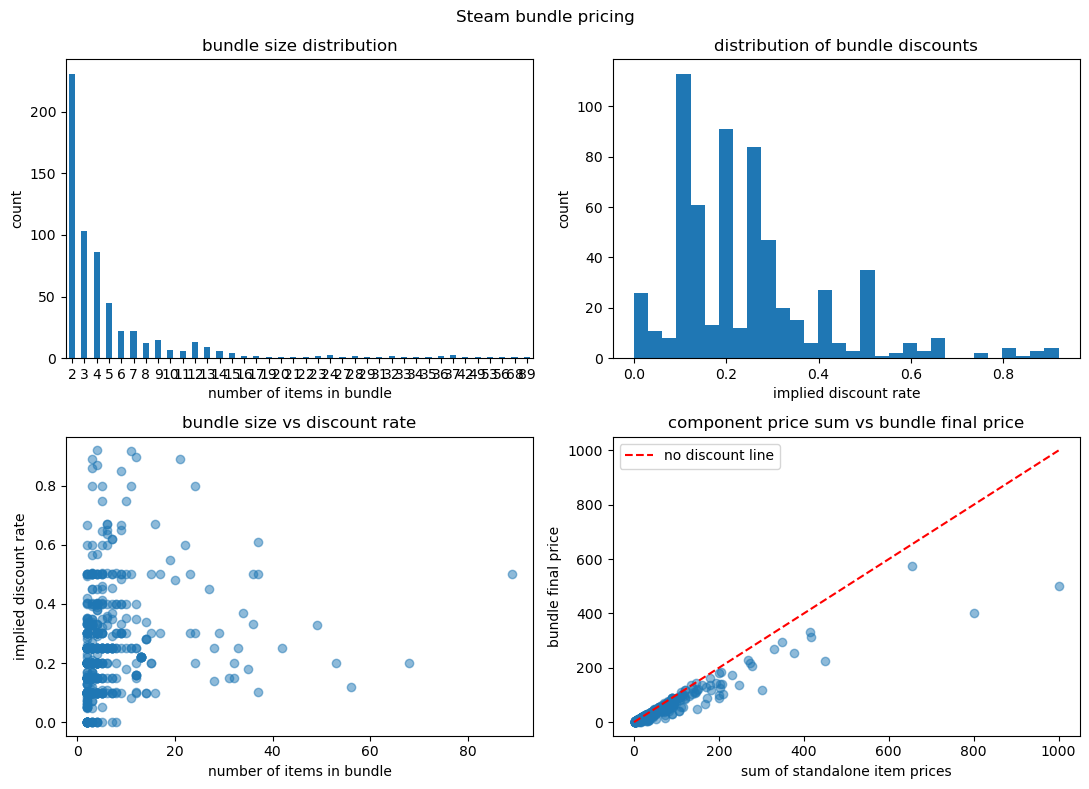

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle('Steam bundle pricing')

# 1. bundle size distribution
ax = axes[0, 0]
bundle_df['n_items'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('number of items in bundle')
ax.set_ylabel('count')
ax.set_title('bundle size distribution')
ax.tick_params(axis='x', rotation=0)

# 2. distribution of implied discount rates
ax = axes[0, 1]
disc = bundle_df['implied_discount_rate'].dropna()
disc = disc[(disc >= 0) & (disc <= 1)]
ax.hist(disc, bins=30)
ax.set_xlabel('implied discount rate')
ax.set_ylabel('count')
ax.set_title('distribution of bundle discounts')

# 3. bundle size vs implied discount rate
ax = axes[1, 0]
valid = bundle_df.dropna(subset=['n_items', 'implied_discount_rate'])
ax.scatter(valid['n_items'], valid['implied_discount_rate'], alpha=0.5)
ax.set_xlabel('number of items in bundle')
ax.set_ylabel('implied discount rate')
ax.set_title('bundle size vs discount rate')

# 4. component price sum vs bundle final price
ax = axes[1, 1]
valid2 = bundle_df.dropna(subset=['component_price_sum', 'final_price'])
ax.scatter(valid2['component_price_sum'], valid2['final_price'], alpha=0.5)
lim = max(valid2['component_price_sum'].max(), valid2['final_price'].max())
ax.plot([0, lim], [0, lim], 'r--', label='no discount line')
ax.set_xlabel('sum of standalone item prices')
ax.set_ylabel('bundle final price')
ax.set_title('component price sum vs bundle final price')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/01_bundle_pricing_eda.png')
plt.show()

## Data quality checks

In [9]:
print('total bundles:', len(bundle_df))
print('duplicate bundle_id:', bundle_df['bundle_id'].duplicated().sum())
print('NaN final_price:', bundle_df['final_price'].isna().sum())
print('NaN component_price_sum:', bundle_df['component_price_sum'].isna().sum())
print('abs_discount < 0 (bundle costs more than parts):', (bundle_df['abs_discount'] < 0).sum())
print('discount_mismatch (>5pp between reported and implied):', bundle_df['discount_mismatch'].sum())


total bundles: 615
duplicate bundle_id: 0
NaN final_price: 0
NaN component_price_sum: 0
abs_discount < 0 (bundle costs more than parts): 3
discount_mismatch (>5pp between reported and implied): 0


In [10]:
bundle_df.to_csv('../outputs/tables/bundle_df.csv', index=False)
bundle_items_df.to_csv('../outputs/tables/bundle_items_df.csv', index=False)
# saved to outputs/table as bundle_df.csv and bundle_items_df.csv